In [1]:
import os
import soundfile as sf
import numpy as np
from IPython.display import Audio 
import matplotlib.pyplot as plt

In [462]:
idx = 25

In [463]:
valid_ambience_paths = os.listdir('/media/diskA/enric/crowdioset/ambience/test/')

In [464]:
valid_events_paths = os.listdir('/media/diskA/enric/crowdioset/events/test/')

In [465]:
main_path = '/media/diskA/enric/musdbmoises/test/'

In [466]:
valid_songs = os.listdir(main_path)

In [467]:
song = valid_songs[idx]
print(song)

Girls Under Glass - We Feel Alright


In [468]:
song_path = main_path+song
print(song_path)

/media/diskA/enric/musdbmoises/test/Girls Under Glass - We Feel Alright


In [469]:
drums, fs = sf.read(song_path +'/drums.wav')
bass, _ = sf.read(song_path +'/bass.wav')
other, _ = sf.read(song_path +'/other.wav')
vocals, _ = sf.read(song_path +'/vocals.wav')
singalong, _ = sf.read(song_path +'/singalong.wav')
noise, _ = sf.read('/media/diskA/enric/crowdioset/ambience/test/' + valid_ambience_paths[idx])
while len(noise) < len(drums):
    noise = np.tile(noise, (2,1))
noise = noise[:len(drums), :]

event, fs_event = sf.read('/media/diskA/enric/crowdioset/events/test/' + valid_events_paths[idx])
event_long = np.zeros_like(drums)
if len(event) > len(event_long):
    event = event[:len(event_long)]

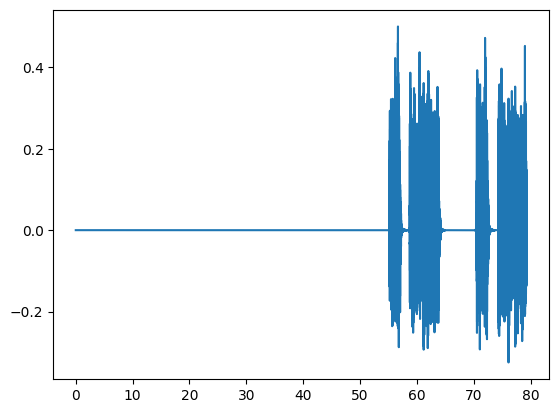

In [470]:
#find starting second in vocals energy

xaxis = np.array(list(range(len(vocals)//4)))

plt.plot(xaxis/fs, vocals[:len(vocals)//4,0])

In [471]:
second = 60
try:
    event_long[int(second*fs) : int(second*fs + len(event))] = event
except:
    tallar = (len(event)+second*fs) - len(event_long)
    event_long[int(second*fs) : int(second*fs + len(event))] = event[:-tallar]

In [472]:
drums = drums[second*fs : second*fs + 4*int(fs), :]
bass = bass[second*fs : second*fs + 4*int(fs), :]
vocals = vocals[second*fs : second*fs + 4*int(fs), :]
other = other[second*fs : second*fs + 4*int(fs), :]
singalong = singalong[second*fs : second*fs + 4*int(fs), :]
noise = noise[second*fs : second*fs + 4*int(fs), :]
event_long = event_long[second*fs : second*fs + 4*int(fs), :]

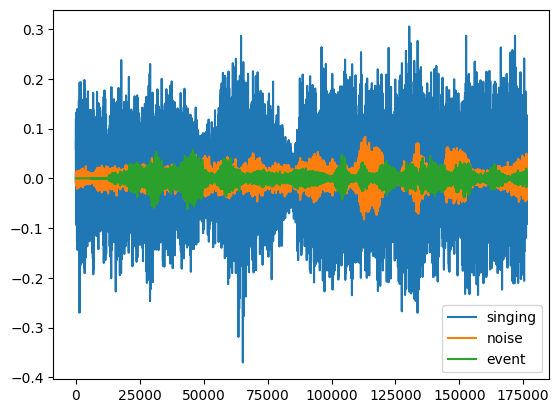

In [478]:
g_sing = 2.
g_noise = .25
g_event = .1

plt.plot(g_sing * singalong[:,0])
plt.plot(g_noise * noise[:,0])
plt.plot(g_event * event_long[:,0])
plt.legend(['singing', 'noise', 'event'])

In [479]:
Audio((g_sing*singalong + g_noise*noise + g_event*event_long).T, rate=44100)

In [480]:
Audio((drums + bass + other + vocals + g_sing * singalong + g_noise * noise + g_event *event_long).T, rate=44100)

In [481]:
drums, fs = sf.read(song_path +'/drums.wav')
singalong, _ = sf.read(song_path +'/singalong.wav')
noise, _ = sf.read('/media/diskA/enric/crowdioset/ambience/test/' + valid_ambience_paths[0])
while len(noise) < len(drums):
    noise = np.tile(noise, (2,1))
noise = noise[:len(drums), :]

event, fs_event = sf.read('/media/diskA/enric/crowdioset/events/test/' + valid_events_paths[0])
event_long = np.zeros_like(drums)
if len(event) > len(event_long):
    event = event[:len(event_long)]
try:
    event_long[int(second*fs) : int(second*fs + len(event))] = event
except:
    tallar = (len(event)+second*fs) - len(event_long)
    event_long[int(second*fs) : int(second*fs + len(event))] = event[:-tallar]

In [482]:
mix = g_sing*singalong + g_noise*noise + g_event*event_long
np.max(mix)

0.43778228759765625

In [483]:
np.min(mix)

-0.447906494140625

In [357]:
mix /= np.max(np.abs(mix))

In [484]:
sf.write(song_path +'/audience.wav', mix, fs)

In [485]:
#check
x, _ = sf.read(song_path +'/audience.wav')
y, _ = sf.read(song_path +'/vocals.wav')
if x.shape != y.shape:
    print('error')